[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/Astroestadistica/blob/main/ITM/Main.ipynb)

---
## 1. Marco Teórico

### 1.1 El Baricentro del Sistema Solar (SSB)

El **Baricentro del Sistema Solar** (Solar System Barycenter, SSB) es el centro de masa de todo el Sistema Solar. Si denotamos la masa del cuerpo $i$ como $m_i$ y su posición como $\mathbf{r}_i$, el SSB se define como:

$$\mathbf{R}_{\rm SSB} = \frac{\sum_i m_i \, \mathbf{r}_i}{\sum_i m_i}$$

Por definición, en el **marco del SSB** el **momento lineal total** del Sistema Solar es cero:

$$\mathbf{P}_{\rm total} = \sum_i m_i \, \mathbf{v}_i = \mathbf{0}$$

Esto lo convierte en un **sistema de referencia inercial** (o casi inercial para propósitos prácticos), lo que significa que las leyes de Newton se aplican directamente sin términos de arrastre ficticios.

| Marco de referencia | Origen | Inercial | Usado por |
|---|---|---|---|
| **SSB eclíptico J2000** | Baricentro del SS | Sí | JPL DE441, SPICE |
| Heliocéntrico eclíptico J2000 | Centro del Sol | $\approx$ Sí (el Sol oscila ~0.01 AU) | Astronomía clásica |
| Geocéntrico | Centro de la Tierra | No (acelerado) | Satélites, observaciones |


### 1.2 El eje eclíptico J2000

Las posiciones y velocidades en el SSB se expresan en el sistema de coordenadas **eclíptico J2000**:
- **Eje X**: apunta hacia el equinoccio vernal del año 2000.0.
- **Eje Z**: perpendicular al plano de la eclíptica (plano de la órbita terrestre).
- **Eje Y**: completa la base derecha $\hat{z} = \hat{x} \times \hat{y}$.

Este es el sistema que usa JPL Horizons por defecto al pedir vectores de estado (`COORD_TYPE=2`).

---

### 1.3 Vectores de Estado: Posición y Velocidad

El **vector de estado** de un cuerpo en el SSB tiene 6 componentes:

$$\mathbf{y}_i = (x_i, y_i, z_i, \dot{x}_i, \dot{y}_i, \dot{z}_i) = (\mathbf{r}_i, \mathbf{v}_i)$$

donde:
- $(x_i, y_i, z_i)$ es la posición en Unidades Astronómicas (UA).
- $(\dot{x}_i, \dot{y}_i, \dot{z}_i)$ es la velocidad en UA/día.

JPL Horizons proporciona estos datos para cualquier cuerpo del Sistema Solar a partir de las **efemérides DE441** (integración numérica de alta precisión).

---

### 1.4 El Parámetro Gravitacional $\mu = GM$

La constante gravitacional universal $G = 6.674 \times 10^{-11}$ m³ kg⁻¹ s⁻² se conoce con una precisión relativa de ~22 ppm, mientras que el **parámetro gravitacional** $\mu_i = GM_i$ se conoce con muchísima mayor precisión (hasta 11 dígitos significativos) mediante observaciones orbitales de naves espaciales.

Por esta razón, en astrodinámica se trabaja directamente con $\mu$ en lugar de $G$ y $M$ por separado:

| Cuerpo | $\mu = GM$ (m³/s²) | $\mu$ (UA³/día²) | $m/M_\odot$ |
|--------|---------------------|------------------|---------------|
| **Sol** | $1.32712 \times 10^{20}$ | $2.9592 \times 10^{-4}$ | $1.0$ |
| **Tierra** | $3.9860 \times 10^{14}$ | $8.8878 \times 10^{-10}$ | $3.003 \times 10^{-6}$ |
| **Luna** | $4.9048 \times 10^{12}$ | $1.0931 \times 10^{-11}$ | $3.694 \times 10^{-8}$ |
| **Apophis** | $\approx 1.8 \times 10^{0}$ | $\approx 4 \times 10^{-24}$ | $\approx 1.4 \times 10^{-20}$ |

---

### 1.5 El Problema de N-Cuerpos: Ecuaciones de Movimiento

Para un sistema de $N$ cuerpos con masas $m_i$ y posiciones $\mathbf{r}_i$ respecto al SSB, las ecuaciones de movimiento de Newton son:

$$\boxed{\ddot{\mathbf{r}}_i = \sum_{j \neq i} \frac{G m_j (\mathbf{r}_j - \mathbf{r}_i)}{|\mathbf{r}_j - \mathbf{r}_i|^3}}$$

En nuestra simulación tenemos $N = 4$ cuerpos: Sol, Tierra, Luna y Apophis. Esto nos da un sistema de $4 \times 3 = 12$ EDOs de segundo orden, o equivalentemente $24$ EDOs de primer orden.

**Constantes de movimiento:**
- Energía mecánica total: $E = \frac{1}{2}\sum_i m_i v_i^2 - \sum_{i<j} \frac{G m_i m_j}{|\mathbf{r}_i - \mathbf{r}_j|}$
- Momento lineal total: $\mathbf{P} = \sum_i m_i \mathbf{v}_i = \mathbf{0}$ (en el SSB)
- Momento angular total: $\mathbf{L} = \sum_i m_i (\mathbf{r}_i \times \mathbf{v}_i)$



In [1]:
!pip install celluloid astropy pymcel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.6 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
import pandas as pd

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
# Constantes de conversión
AU_m   = pc.constantes.au      # 1 UA en metros
day_s  = pc.constantes.día     # 1 día en segundos
yr_d   = pc.constantes.yr / pc.constantes.día  # 1 año en días
G_SI   = pc.constantes.G       # Constante gravitacional [m^3 kg^-1 s^-2]
c_luz  = pc.constantes.c       # Velocidad de la luz [m/s]

# Factor de conversión de mu: m^3/s^2 -> UA^3/día^2
fac_mu = day_s**2 / AU_m**3

In [4]:
# Constantes gravitacionales (SI) m^3/s^2
mu_sun_SI      = pc.constantes.mu_sun
mu_mercury_SI  = pc.constantes.mu_mercury
mu_venus_SI    = pc.constantes.mu_venus
mu_earth_SI    = pc.constantes.mu_earth
mu_moon_SI     = pc.constantes.mu_moon
mu_mars_SI     = pc.constantes.mu_mars
mu_jupiter_SI  = pc.constantes.mu_jupiter
mu_saturn_SI   = pc.constantes.mu_saturn
mu_uranus_SI   = pc.constantes.mu_uranus
mu_neptune_SI  = pc.constantes.mu_neptune

m_apophis      = 2.7e10                          # kg
mu_apophis_SI  = G_SI * m_apophis                # m^3/s^2

# Construcción del DataFrame
datos_mu = [
    ('Sol',       mu_sun_SI,     mu_sun_SI * fac_mu,     1.0),
    ('Mercurio',  mu_mercury_SI, mu_mercury_SI * fac_mu, mu_mercury_SI / mu_sun_SI),
    ('Venus',     mu_venus_SI,   mu_venus_SI * fac_mu,   mu_venus_SI / mu_sun_SI),
    ('Tierra',    mu_earth_SI,   mu_earth_SI * fac_mu,   mu_earth_SI / mu_sun_SI),
    ('Luna',      mu_moon_SI,    mu_moon_SI * fac_mu,    mu_moon_SI / mu_sun_SI),
    ('Marte',     mu_mars_SI,    mu_mars_SI * fac_mu,    mu_mars_SI / mu_sun_SI),
    ('Jupiter',   mu_jupiter_SI, mu_jupiter_SI * fac_mu, mu_jupiter_SI / mu_sun_SI),
    ('Saturno',   mu_saturn_SI,  mu_saturn_SI * fac_mu,  mu_saturn_SI / mu_sun_SI),
    ('Urano',     mu_uranus_SI,  mu_uranus_SI * fac_mu,  mu_uranus_SI / mu_sun_SI),
    ('Neptuno',   mu_neptune_SI, mu_neptune_SI * fac_mu, mu_neptune_SI / mu_sun_SI),
    ('Apophis',   mu_apophis_SI, mu_apophis_SI * fac_mu, mu_apophis_SI / mu_sun_SI),
]

cuerpos_mu = pd.DataFrame(datos_mu, columns=['Cuerpo', 'mu (m^3/s^2)', 'mu (UA^3/d^2)', 'm/M_sol'])
cuerpos_mu

,Cuerpo,mu (m^3/s^2),mu (UA^3/d^2),m/M_sol
0,Sol,1.327124e+20,2.959122e-04,1.000000e+00
1,Mercurio,2.203187e+13,4.912500e-11,1.660121e-07
2,Venus,3.248586e+14,7.243452e-10,2.447838e-06
3,Tierra,3.986004e+14,8.887692e-10,3.003490e-06
4,Luna,4.902800e+12,1.093189e-11,3.694303e-08
5,Marte,4.282838e+13,9.549549e-11,3.227156e-07
6,Jupiter,1.267128e+17,2.825346e-07,9.547919e-04
7,Saturno,3.794058e+16,8.459706e-08,2.858857e-04
8,Urano,5.794556e+15,1.292027e-08,4.366250e-05
9,Neptuno,6.836527e+15,1.524357e-08,5.151384e-05


In [5]:
CUERPOS = [
    ('Sol',     '10',    'majorbody', mu_sun_SI),
    ('Tierra',  '399',   'majorbody', mu_earth_SI),
    ('Luna',    '301',   'majorbody', mu_moon_SI),
    ('Apophis', '99942', 'smallbody', mu_apophis_SI),
]

In [6]:
def Estados(cuerpos, propiedades, epochs):
    VectorEstadoSI = {}
    for nombre, id in cuerpos:
        _, _, salida = pc.consulta_horizons(
            id=id,
            location="@0",
            datos="vectors",
            propiedades=propiedades,
            epochs=epochs,
        )
        VectorEstadoSI[nombre] = np.array(salida, dtype=float).reshape(-1)
    return VectorEstadoSI

def UnidadesCanonicas(EstadosSI, MasasSI, UL=1.495978707e11, UM=1.98847e30):

    UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)
    vel_unit = UL / UT

    EstadoCanonico = {}
    for nombre, vec in EstadosSI.items():
        x, y, z, vx, vy, vz = vec
        EstadoCanonico[nombre] = np.array([
            x / UL,
            y / UL,
            z / UL,
            vx / vel_unit,
            vy / vel_unit,
            vz / vel_unit,
        ])

    MasasCanonico = {nombre: MasasSI[nombre] / UM for nombre in MasasSI}
    return EstadoCanonico, MasasCanonico, UL, UM, UT, Gc

In [7]:
#epochs_ini = {'start': '2026-04-11', 'stop': '2026-04-12', 'step': '1d'}
epochs_ini = "2026-04-11"

In [8]:
def Estados(cuerpos, propiedades, epochs):
    VectorEstadoSI = {}
    for nombre, id in cuerpos:
        _, _, salida = pc.consulta_horizons(
            id=id,
            location="@0",
            datos="vectors",
            propiedades=propiedades,
            epochs=epochs,
        )
        # Convertir la salida a un vector único [x, y, z, vx, vy, vz]
        VectorEstadoSI[nombre] = np.array(salida, dtype=float).reshape(-1)
    return VectorEstadoSI

def UnidadesCanonicas(EstadosSI, MasasSI, UL=1.495978707e11, UM=1.98847e30):
    UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)
    vel_unit = UL / UT

    EstadoCanonico = {}
    for nombre, vec in EstadosSI.items():
        # Asegurarse de que el vector tenga 6 elementos: [x, y, z, vx, vy, vz]
        if len(vec) != 6:
            raise ValueError(f"El vector de estado para {nombre} debe tener 6 elementos: [x, y, z, vx, vy, vz]")
        x, y, z, vx, vy, vz = vec
        EstadoCanonico[nombre] = np.array([
            x / UL,
            y / UL,
            z / UL,
            vx / vel_unit,
            vy / vel_unit,
            vz / vel_unit,
        ])

    MasasCanonico = {nombre: MasasSI[nombre] / UM for nombre in MasasSI}
    return EstadoCanonico, MasasCanonico, UL, UM, UT, Gc

In [9]:
CUERPOS = [
    ('Sol',       '10',    'majorbody', mu_sun_SI),
    ('Mercurio',  '199',   'majorbody', mu_mercury_SI),
    ('Venus',     '299',   'majorbody', mu_venus_SI),
    ('Tierra',    '399',   'majorbody', mu_earth_SI),
    ('Luna',      '301',   'majorbody', mu_moon_SI),
    ('Marte',     '499',   'majorbody', mu_mars_SI),
    ('Jupiter',   '599',   'majorbody', mu_jupiter_SI),
    ('Saturno',   '699',   'majorbody', mu_saturn_SI),
    ('Urano',     '799',   'majorbody', mu_uranus_SI),
    ('Neptuno',   '899',   'majorbody', mu_neptune_SI),
    ('Apophis',   '99942', 'smallbody', mu_apophis_SI),
]

epochs_ini = '2026-04-11'  # Solo una fecha

estados_ini = {}

for nombre, horizons_id, id_type, mu in CUERPOS:
    print(f'Consultando Horizons para {nombre} (ID={horizons_id})...')
    try:
        # pc.consulta_horizons devuelve una tupla: (tabla, tiempo_jd, vector_estado)
        tabla, tiempo_jd, vector_estado = pc.consulta_horizons(
            id=horizons_id,
            location='@0',
            epochs=epochs_ini,
            datos='vectors',
        )
        # El vector de estado ya está en el formato [x, y, z, vx, vy, vz]
        estados_ini[nombre] = vector_estado
    except Exception as e:
        print(f"Error al consultar {nombre}: {e}")

# Verificar el resultado
for nombre, vector in estados_ini.items():
    print(f"{nombre}: {vector}")

Consultando Horizons para Sol (ID=10)...
Consultando Horizons para Mercurio (ID=199)...
Consultando Horizons para Venus (ID=299)...
Consultando Horizons para Tierra (ID=399)...
Consultando Horizons para Luna (ID=301)...
Consultando Horizons para Marte (ID=499)...
Consultando Horizons para Jupiter (ID=599)...
Consultando Horizons para Saturno (ID=699)...
Consultando Horizons para Urano (ID=799)...
Consultando Horizons para Neptuno (ID=899)...
Consultando Horizons para Apophis (ID=99942)...
Sol: [-3.53325160e+08 -8.17897981e+08  1.76187615e+07  1.19440312e+01
  2.01470051e+00 -2.43515046e-01]
Mercurio: [ 6.27496227e+09 -6.91377417e+10 -6.17362274e+09  3.87268880e+04
  7.20531335e+03 -2.96241057e+03]
Venus: [ 2.53805657e+10  1.03852452e+11 -2.91861134e+07 -3.41147727e+04
  8.19176656e+03  2.08136778e+03]
Tierra: [-1.40521419e+11 -5.39341377e+10  2.18549253e+07  1.00748836e+04
 -2.79712608e+04  5.00676680e-01]
Luna: [-1.40325271e+11 -5.42785809e+10 -2.09805396e+05  1.09052134e+04
 -2.74456

In [10]:
print(f'Época inicial de la simulación: {epochs_ini}')
print(f'Cuerpos incluidos en la simulación: {[c[0] for c in CUERPOS]}')

Época inicial de la simulación: 2026-04-11
Cuerpos incluidos en la simulación: ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Neptuno', 'Apophis']


In [11]:
estados_ini

{'Sol': array([-3.53325160e+08, -8.17897981e+08,  1.76187615e+07,  1.19440312e+01,
         2.01470051e+00, -2.43515046e-01]),
 'Mercurio': array([ 6.27496227e+09, -6.91377417e+10, -6.17362274e+09,  3.87268880e+04,
         7.20531335e+03, -2.96241057e+03]),
 'Venus': array([ 2.53805657e+10,  1.03852452e+11, -2.91861134e+07, -3.41147727e+04,
         8.19176656e+03,  2.08136778e+03]),
 'Tierra': array([-1.40521419e+11, -5.39341377e+10,  2.18549253e+07,  1.00748836e+04,
        -2.79712608e+04,  5.00676680e-01]),
 'Luna': array([-1.40325271e+11, -5.42785809e+10, -2.09805396e+05,  1.09052134e+04,
        -2.74456191e+04,  7.29104911e+01]),
 'Marte': array([ 2.00381950e+11, -5.05901404e+10, -5.94761265e+09,  6.77159888e+03,
         2.55910396e+04,  3.70259763e+02]),
 'Jupiter': array([-3.58940704e+11,  6.97555170e+11,  5.13944029e+09, -1.17732844e+04,
        -5.36065309e+03,  2.85708099e+02]),
 'Saturno': array([ 1.41255449e+12,  1.20864442e+11, -5.83434290e+10, -1.35428646e+03,
       

# Construcción del sistema en pymcel

In [12]:
# ─── Construcción del sistema para pymcel ────────────────────────────────

sistema = []
nombres_sim = []  # para etiquetas

for nombre, horizons_id, id_type, mu_si in CUERPOS:
    data = estados_ini[nombre]

    # Obtener mu en UA^3/d^2 del DataFrame cuerpos_mu
    # This assumes 'cuerpos_mu' DataFrame is correctly populated and 'nombre' exists in it.
    mu_ua_day = cuerpos_mu.loc[cuerpos_mu['Cuerpo'] == nombre, 'mu (UA^3/d^2)'].iloc[0]

    r_au = np.array(data[:3]) / AU_m
    v_au_day = np.array(data[3:]) * day_s / AU_m

    sistema.append(dict(
        m = mu_ua_day,   # μ = GM en UA^3/d^2 (G=1 canónico)
        r = r_au.tolist(), # Position vector in AU
        v = v_au_day.tolist(), # Velocity vector in AU/day
    ))
    nombres_sim.append(nombre)

# Imprimir configuración
print('Sistema de simulación:')
print(f'{"Cuerpo":<10} {"μ (UA³/d²)":>16} {"r [UA]":<40} {"v [UA/d]"}')
print('-'*100)
for i, (cuerpo, s) in enumerate(zip(nombres_sim, sistema)):
    rv = np.array(s['r'])
    vv = np.array(s['v'])
    print(f'{cuerpo:<10} {s["m"]:>16.4e}  [{rv[0]:+.4f}, {rv[1]:+.4f}, {rv[2]:+.5f}]  '
          f'[{vv[0]:+.6f}, {vv[1]:+.6f}, {vv[2]:+.6f}]')


Sistema de simulación:
Cuerpo           μ (UA³/d²) r [UA]                                   v [UA/d]
----------------------------------------------------------------------------------------------------
Sol              2.9591e-04  [-0.0024, -0.0055, +0.00012]  [+0.000007, +0.000001, -0.000000]
Mercurio         4.9125e-11  [+0.0419, -0.4622, -0.04127]  [+0.022367, +0.004161, -0.001711]
Venus            7.2435e-10  [+0.1697, +0.6942, -0.00020]  [-0.019703, +0.004731, +0.001202]
Tierra           8.8877e-10  [-0.9393, -0.3605, +0.00015]  [+0.005819, -0.016155, +0.000000]
Luna             1.0932e-11  [-0.9380, -0.3628, -0.00000]  [+0.006298, -0.015851, +0.000042]
Marte            9.5495e-11  [+1.3395, -0.3382, -0.03976]  [+0.003911, +0.014780, +0.000214]
Jupiter          2.8253e-07  [-2.3994, +4.6629, +0.03436]  [-0.006800, -0.003096, +0.000165]
Saturno          8.4597e-08  [+9.4423, +0.8079, -0.39000]  [-0.000782, +0.005546, -0.000065]
Urano            1.2920e-08  [+9.5334, +16.9722, -0.06

In [19]:
# Vector de tiempos
N_PASOS = 1000
T_FINAL = 2*365.0    # días
ts = np.linspace(0.0, T_FINAL, N_PASOS)

# Integración de N-Cuerpos con pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

(np.float64(-0.43495061703814614),
 np.float64(0.3990776975031056),
 np.float64(-0.5069380433134495),
 np.float64(0.3434048932252992))

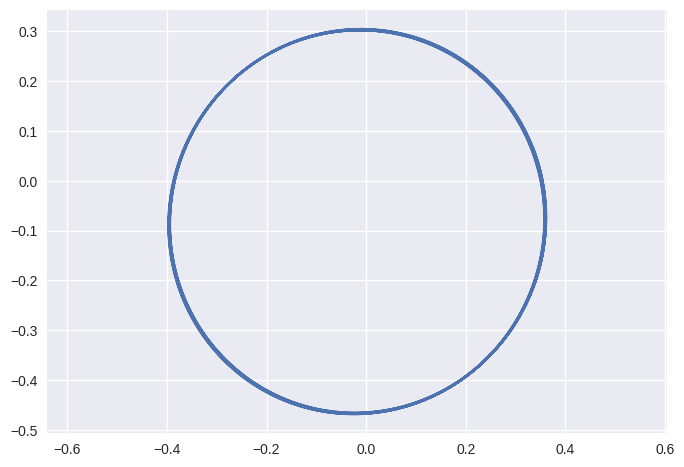

In [20]:
plt.plot(rs[1,:,0],rs[1,:,1])
plt.axis("equal")

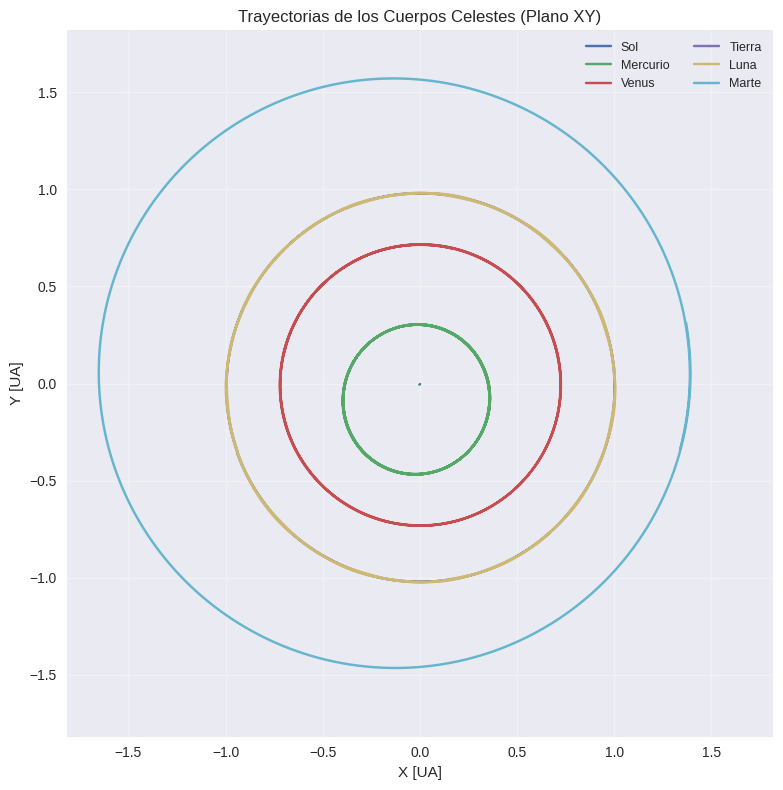

In [21]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10, 8))

# Calculate the maximum extent of the orbits in AU for dynamic plot limits
max_coord = 0

# Find the index of 'Marte'
marte_index = nombres_sim.index('Marte')

# Iterate only up to and including Mars
for i, nombre in enumerate(nombres_sim[:marte_index + 1]):
    # rs is already in AU (canonical unit system from the integration)
    r_plot_x = rs[i, :, 0]
    r_plot_y = rs[i, :, 1]
    plt.plot(r_plot_x, r_plot_y, label=nombre)

    # Update max_coord to encompass all trajectories
    max_x = np.max(np.abs(r_plot_x))
    max_y = np.max(np.abs(r_plot_y))
    max_coord = max(max_coord, max_x, max_y)

# Set plot limits with some padding
plot_limit = max_coord * 1.1
plt.xlim(-plot_limit, plot_limit)
plt.ylim(-plot_limit, plot_limit)

plt.xlabel('X [UA]')
plt.ylabel('Y [UA]')
plt.title('Trayectorias de los Cuerpos Celestes (Plano XY)')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

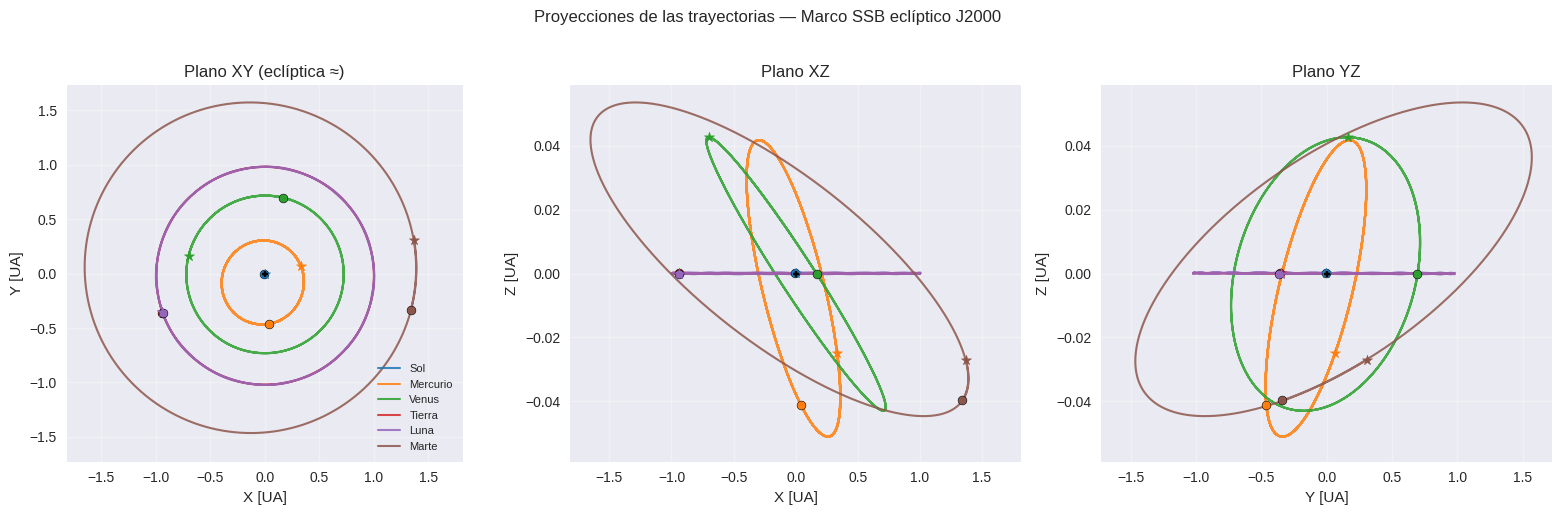

In [26]:
# Proyecciones de órbitas en planos coordenados
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

planos = [
    (0, 1, 'X [UA]', 'Y [UA]', 'Plano XY (eclíptica ≈)'),
    (0, 2, 'X [UA]', 'Z [UA]', 'Plano XZ'),
    (1, 2, 'Y [UA]', 'Z [UA]', 'Plano YZ'),
]

# Colors for each body
colores = {nombre: plt.cm.tab10(i) for i, nombre in enumerate(nombres_sim)}

# Find the index of 'Marte'
marte_index = nombres_sim.index('Marte')

for ax, (ix, iy, xl, yl, titulo) in zip(axes, planos):
    max_val_x_current_plane = 0
    max_val_y_current_plane = 0

    for i, nombre in enumerate(nombres_sim[:marte_index + 1]): # Plot only up to Mars
        tray = rs[i]
        c = colores[nombre]
        ax.plot(tray[:, ix], tray[:, iy], '-', color=c, linewidth=1.5,
                label=nombre, alpha=0.85)
        # Punto inicial
        ax.scatter(tray[0, ix], tray[0, iy], s=40, color=c,
                   edgecolors='k', linewidths=0.4, zorder=5)
        # Punto final (estrella)
        ax.scatter(tray[-1, ix], tray[-1, iy], s=60, color=c, marker='*', zorder=5)

        # Update max_val_x and max_val_y for the current plane independently
        max_val_x_current_plane = max(max_val_x_current_plane, np.max(np.abs(tray[:, ix])))
        max_val_y_current_plane = max(max_val_y_current_plane, np.max(np.abs(tray[:, iy])))

    # Set plot limits with some padding based on the current plane's max coordinates
    plot_limit_x = max_val_x_current_plane * 1.1
    plot_limit_y = max_val_y_current_plane * 1.1

    ax.set_xlim(-plot_limit_x, plot_limit_x)
    ax.set_ylim(-plot_limit_y, plot_limit_y)

    # SSB (centro en origen)
    ax.scatter(0, 0, s=25, color='k', marker='+', zorder=6)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(titulo)

    # Conditionally set aspect ratio to amplify vertical axis for XZ and YZ
    if titulo == 'Plano XY (eclíptica ≈)':
        ax.set_aspect('equal', adjustable='box') # Maintain equal aspect ratio for XY plane
    else:
        ax.set_aspect('auto', adjustable='box') # Let matplotlib automatically adjust for XZ and YZ

    if ax == axes[0]: # Add legend only to the first subplot
        ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Proyecciones de las trayectorias — Marco SSB eclíptico J2000', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()